<a href="https://colab.research.google.com/github/nkocjan/computational-intelligence-methods/blob/dev/lab01/lab01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Zadanie 1**


Proszę stworzyć zestaw punktów należących do dwóch klas: K1 i K2. Punkty z klasy K1 powinny być losowane z rozkładu normalnego o średniej [0, -1] i wariancji 1. Punkty z klasy K2 powinny pochodzić z rozkładu normalnego o średniej [1, 1] i wariancji 1. Całościowo zbiór powinien zawierać 200 punktów, po 100 dla każdej klasy.


In [62]:
from sklearn.linear_model import Perceptron
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
from mpl_toolkits.mplot3d import Axes3D

K1 = np.random.normal([0,-1], 1, [100,2])
K2 = np.random.normal([1,1], 1, [100,2])

Należy wybrać zbiory uczące o następującej liczebności: 5, 10, 20 oraz 100.

 Dla każdego wariantu podziału znalezy znaleźć równanie prostej, która najlepiej oddziela klasy K1 i K2.Uzyskaną prostą należy zaprezentować razem z punktami testowymi i linią (hiperpłaszczyzną), która oddziela klasy. Następnie należy ocenić to jak dobrze klasyfikator działa od proporcji danych uczących i testujących.


1.0


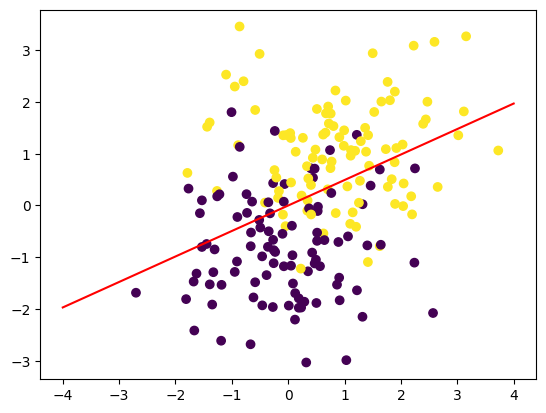

1.0


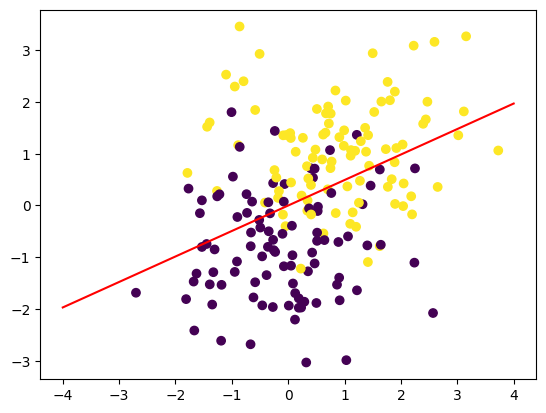

0.7


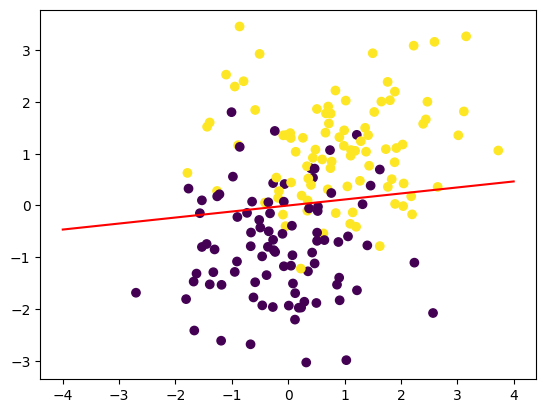

0.74


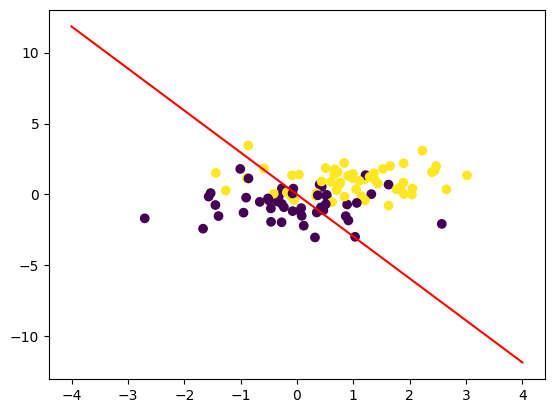

In [3]:
X = np.vstack((K1, K2))
y = np.hstack((np.zeros(100), np.ones(100)))

train_sizes = [5, 10, 20, 100]

results = []

for i, train_size in enumerate(train_sizes):
    X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=train_size, random_state=0)

    perceptron = Perceptron(tol=1e-3, max_iter=500)
    perceptron.fit(X_train, y_train)

    print(perceptron.score(X_train, y_train))

    x1 = np.linspace(-4,4,100)
    x2 = -(1./perceptron.coef_[0][1])*(perceptron.coef_[0][0]*x1+perceptron.intercept_[0])
    plt.plot(x1, x2, '-r')
    plt.scatter(np.array(X_test)[:,0], np.array(X_test)[:,1], c=y_test)
    plt.show()


**Zadanie 2**

Analiza próbek benzyny wykazała że może ona być przypisana do dwóch klas czystości A i B (dla potrzeb zadania można je oznaczyć 0 i 1). Proszę skorzystać z pliku fuel.txt, w którym pierwsze trzy kolumny to właściwości fizykochemiczne próbek, czwarta kolumna - klasa czystości. Proszę sprawdzić skuteczność sieci opartej o pojedynczy neuron do klasyfikacji w tym problemie, porównując wyniki dla pięciokrotnego uczenia sieci. Proszę potraktować wszystkie dane jako dane uczące.


2.1 Wczytanie danych z pliku

In [47]:
data = pd.read_csv('../fuel.txt', delimiter=",")

2.2 Normalizacja danych do zakresu 0 - 100

In [48]:
features = ['c_1', 'c_2', 'c_3']
scaler = MinMaxScaler(feature_range=(0, 100))
data[features] = scaler.fit_transform(data[features])

Rozbiór danych na testy oraz wyniki, podmiana A na 0 i B na 1

In [49]:
data['purity_class'] = np.where(data['purity_class'] == 'B', 1, 0).astype(int)
X = data.iloc[:,:-1].values
y = data.iloc[:, -1].values

Pięciokrotne wyznaczenie perceptronu, wypisanie wyniku, wygenerowanie wykresu 3D

0.9


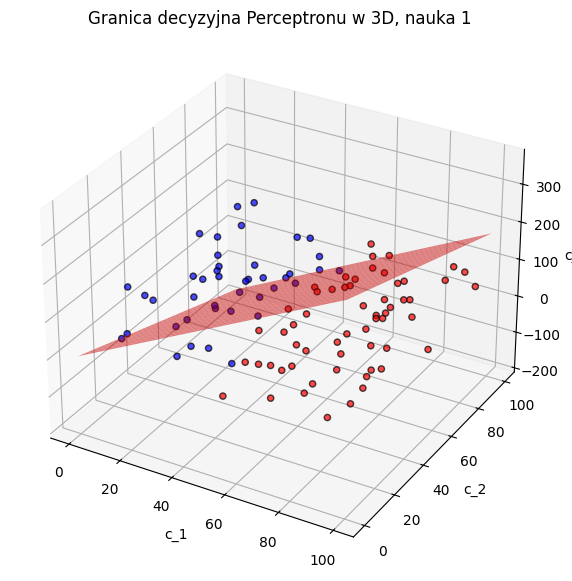

0.9


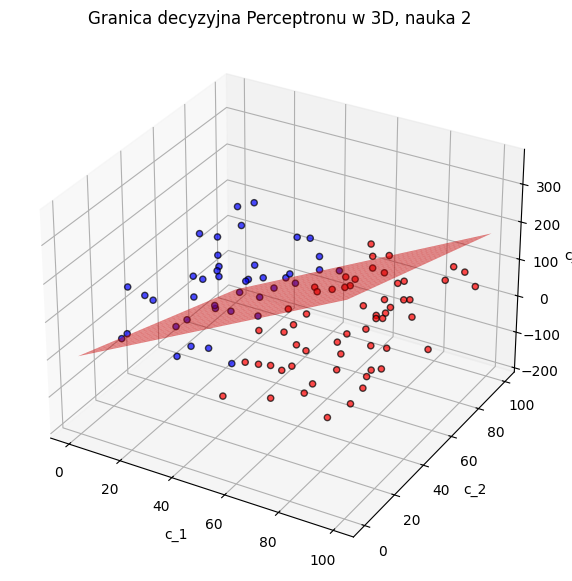

0.9


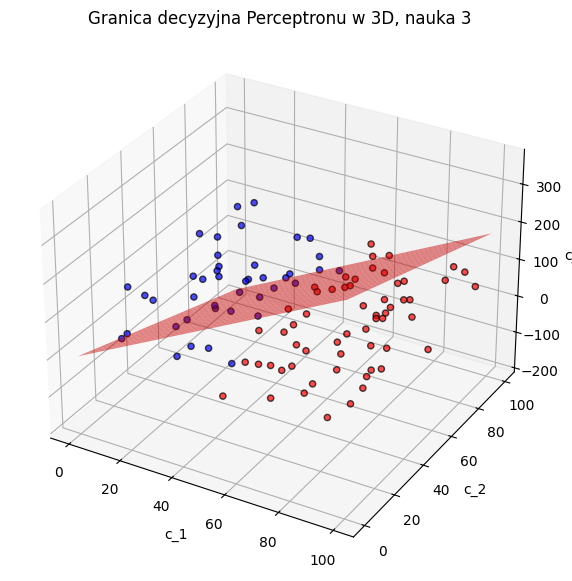

0.9


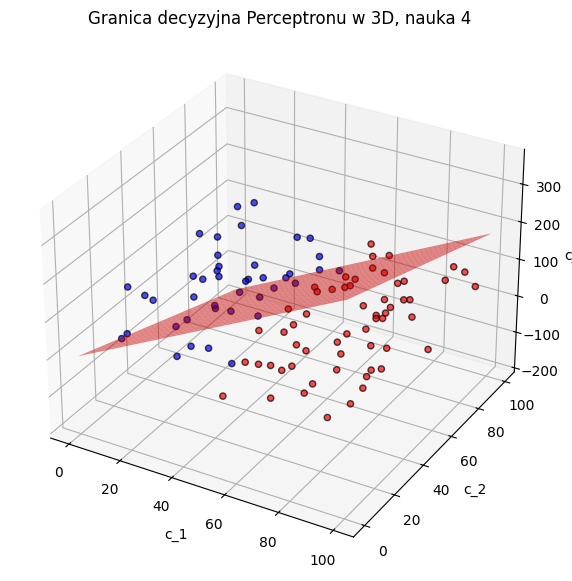

0.9


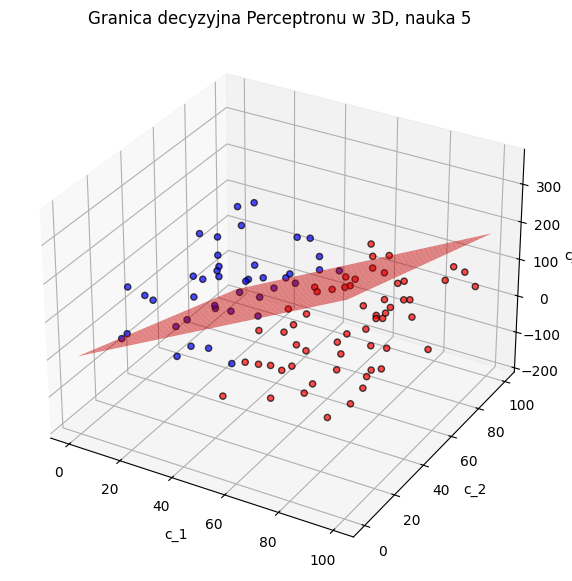

In [67]:
for i in range(5):
  perceptron = Perceptron(tol=1e-3, max_iter=100)
  perceptron.fit(X, y)
  print(perceptron.score(X,y))
  w = perceptron.coef_[0]
  b = perceptron.intercept_[0]

  x1_range = np.linspace(X[:, 0].min(), X[:, 0].max(), 30)
  x2_range = np.linspace(X[:, 1].min(), X[:, 1].max(), 30)
  x1_grid, x2_grid = np.meshgrid(x1_range, x2_range)

  x3_grid = -(w[0] / w[2]) * x1_grid - (w[1] / w[2]) * x2_grid - (b / w[2])

  fig = plt.figure(figsize=(10, 7))
  ax = fig.add_subplot(111, projection='3d')

  ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=y, cmap='bwr', alpha=0.7, edgecolors='k')
  ax.plot_surface(x1_grid, x2_grid, x3_grid, color='red', alpha=0.5)

  ax.set_xlabel("c_1")
  ax.set_ylabel("c_2")
  ax.set_zlabel("c_3")
  ax.set_title("Granica decyzyjna Perceptronu w 3D, nauka " + (i + 1).__str__())

  plt.show()

